# 3. Análisis bidimensional

Sección 9.10.4.1.3 del enunciado. Se estudia la relación de cada variable con `default` y la
relación entre las variables independientes (multicolinealidad). Las pruebas estadísticas y las
tablas usan los 1.348.059 préstamos. Los gráficos de densidad (violín y KDE) usan una muestra
aleatoria de 100.000 préstamos y los de dispersión (pairplot y scatter matrix) una de 5.000, para
que sean legibles y se generen en tiempos razonables; ninguna conclusión depende solo de ellos.

In [1]:
import sys
import warnings

sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

import estadistica as est
import utils as u

u.estilo()
pd.set_option("display.max_columns", 30, "display.width", 180, "display.max_rows", 120)
df = u.cargar_prestamos(u.NUM_EDA + u.CAT_EDA + ["default"])
df.loc[(df["dti"] < 0) | (df["dti"] > 100), "dti"] = np.nan   # códigos inválidos (capítulo 2)
y = df["default"]
muestra = df.sample(100_000, random_state=u.SEMILLA)
muestra_chica = df.sample(5_000, random_state=u.SEMILLA)
print(f"{len(df):,} préstamos; tasa de default {100 * y.mean():.2f} %")

1,348,059 préstamos; tasa de default 19.98 %


## 3.1 Variables numéricas frente a `default`

### 3.1.1 Diagramas de caja por clase

Se omiten los puntos atípicos para que las cajas sean comparables; el capítulo 2 ya los describió.

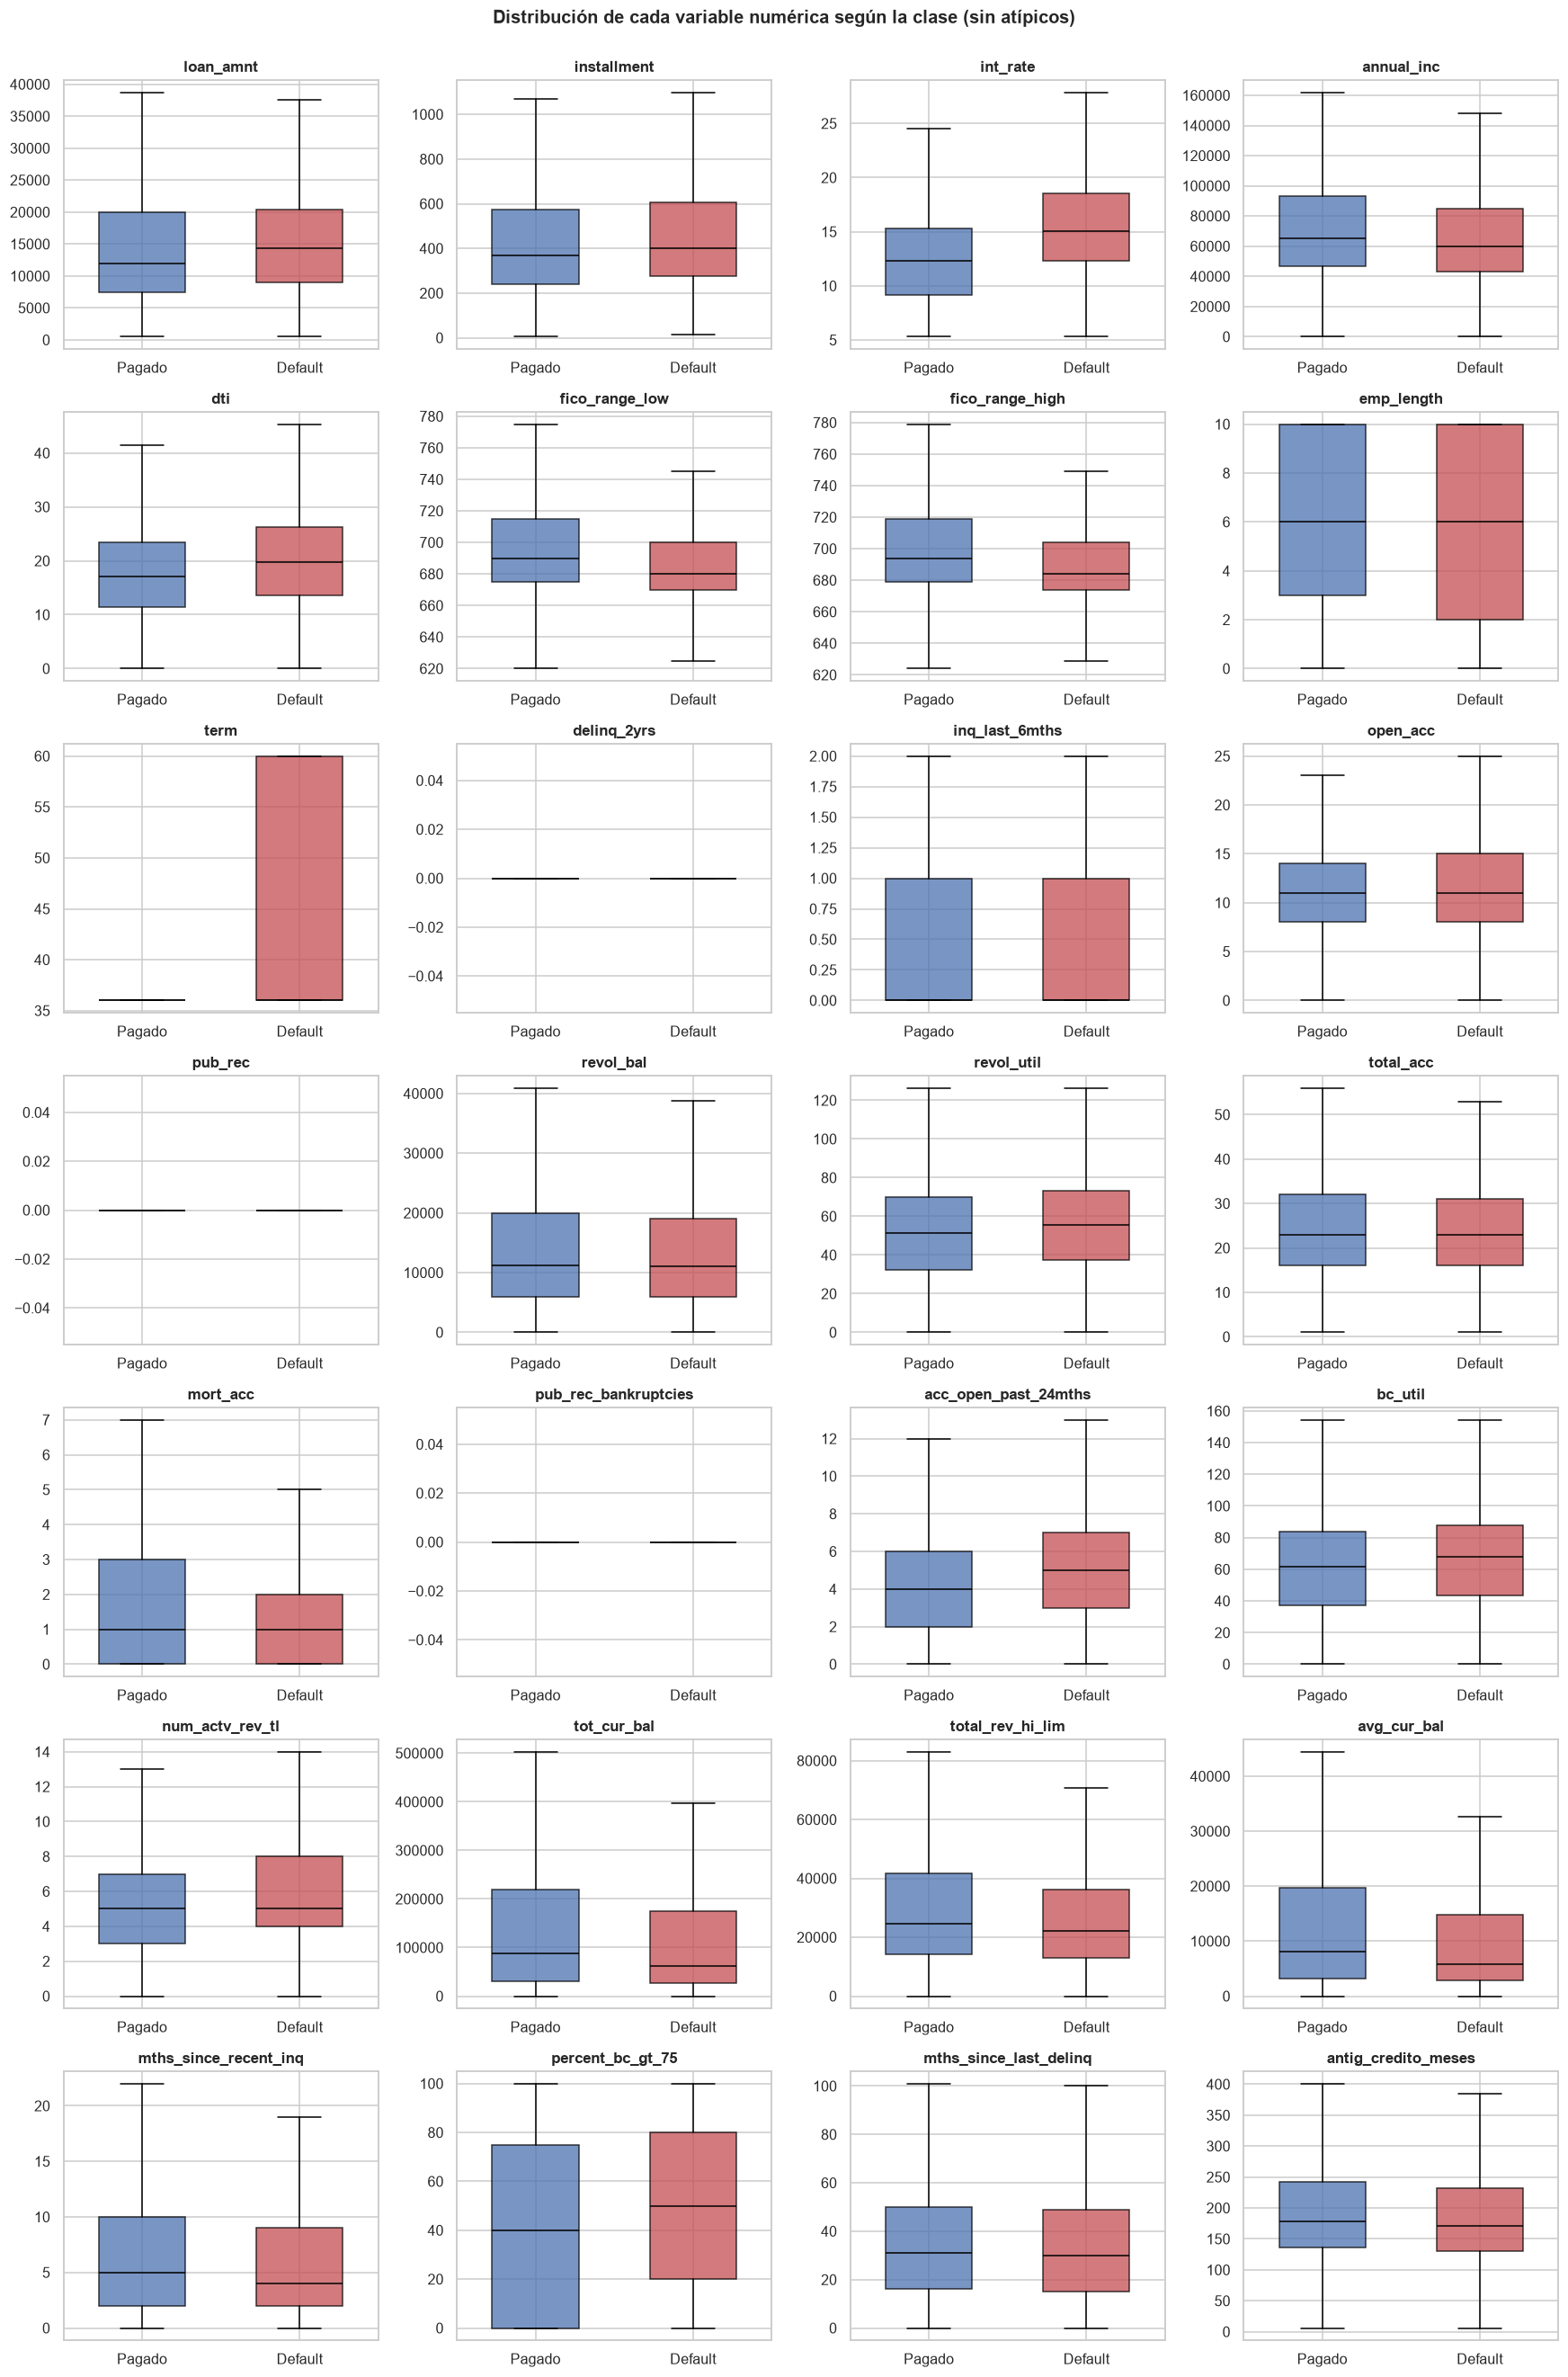

In [2]:
fig, axes = plt.subplots(7, 4, figsize=(16, 24))
for ax, c in zip(axes.ravel(), u.NUM_EDA):
    datos = [df.loc[y == k, c].dropna() for k in (0, 1)]
    b = ax.boxplot(datos, tick_labels=["Pagado", "Default"], showfliers=False, patch_artist=True,
                   widths=0.55, medianprops={"color": "black"})
    for caja, k in zip(b["boxes"], (0, 1)):
        caja.set_facecolor(u.PALETA[k])
        caja.set_alpha(0.75)
    ax.set_title(c)
fig.suptitle("Distribución de cada variable numérica según la clase (sin atípicos)", y=1.0,
             fontsize=13, weight="bold")
fig.tight_layout()
u.guardar_fig(fig, "03_boxplots_clase")
plt.show()

Las cajas de los préstamos en default están desplazadas hacia valores más riesgosos en las
variables de precio y capacidad de pago: tasa de interés más alta (mediana 15,1 % frente a 12,3 %),
plazo de 60 meses más frecuente, FICO más bajo (684 frente a 694), `dti` mayor y más cuentas
abiertas en los últimos 24 meses. En las variables de saldo (`avg_cur_bal` y `tot_cur_bal`, con
medianas de 5.748 y 61.197 dólares entre los defaults frente a 8.018 y 87.442 entre los pagados)
ocurre lo contrario, y en `mort_acc` (número de hipotecas) la media es menor entre los defaults
(1,37 frente a 1,75), aunque las medianas coinciden: los prestatarios con más patrimonio
financiero pagan más. En
conteos como `delinq_2yrs` o `pub_rec` las cajas son casi idénticas, lo que anticipa un poder
discriminante bajo.

### 3.1.2 Gráficos de violín de las variables más discriminantes

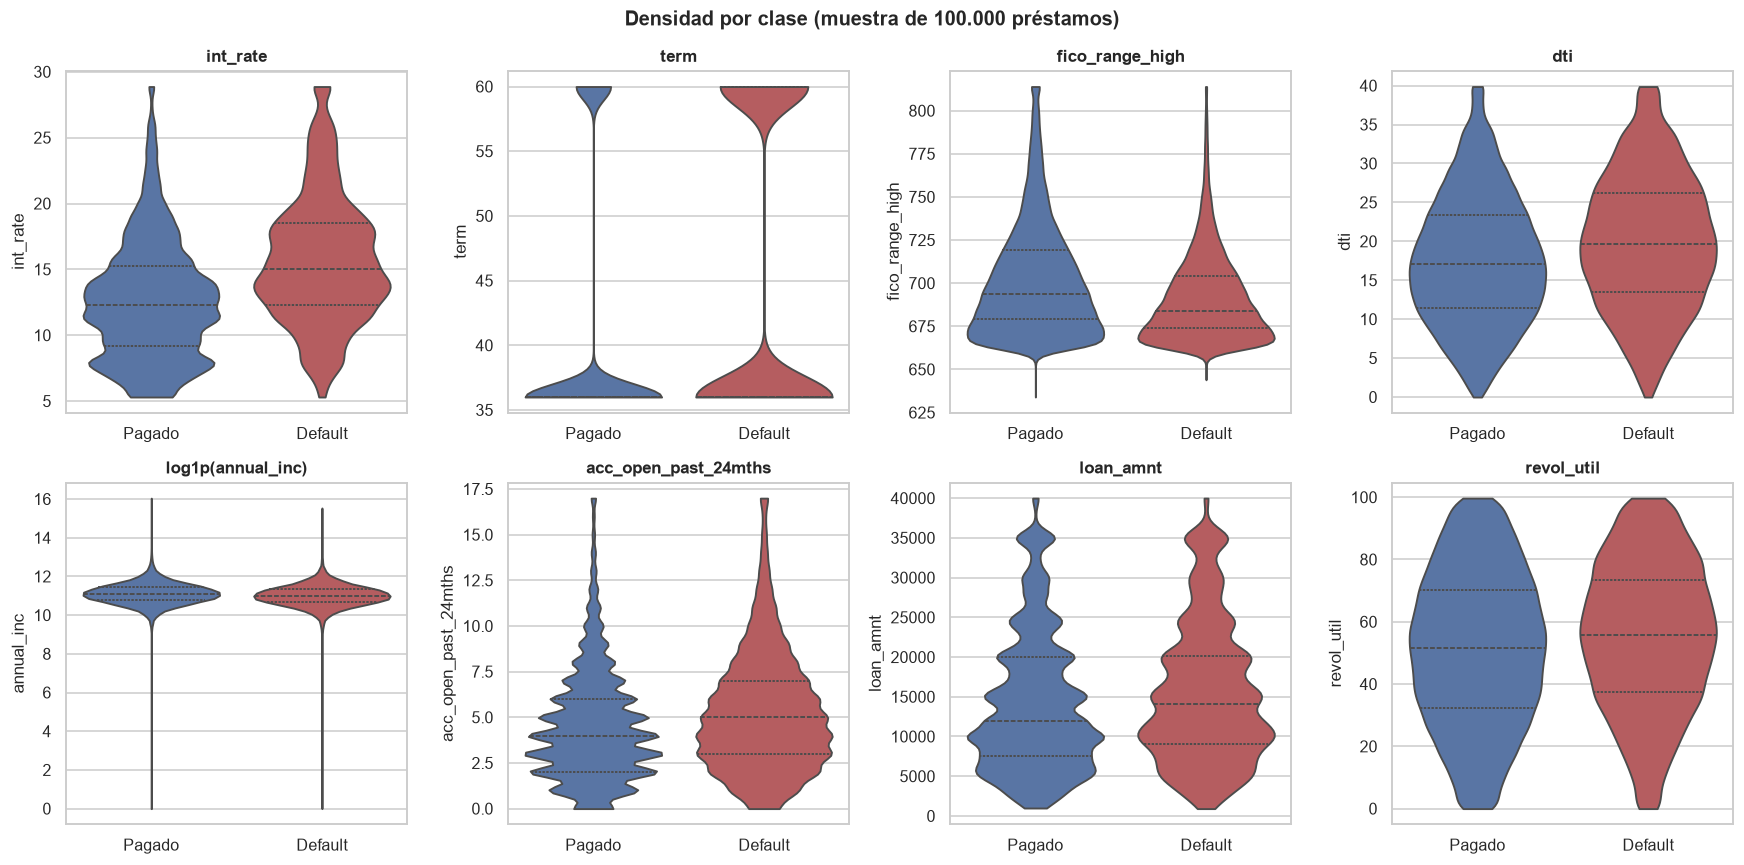

In [3]:
clave = ["int_rate", "term", "fico_range_high", "dti", "annual_inc", "acc_open_past_24mths",
         "loan_amnt", "revol_util"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, c in zip(axes.ravel(), clave):
    d = muestra[[c, "default"]].dropna()
    if c == "annual_inc":
        d[c] = np.log1p(d[c])
        titulo = "log1p(annual_inc)"
    else:
        d[c] = d[c].clip(upper=d[c].quantile(0.995))
        titulo = c
    sns.violinplot(data=d, x="default", y=c, hue="default", palette=u.PALETA, ax=ax, cut=0,
                   inner="quartile", legend=False)
    ax.set_title(titulo)
    ax.set_xticklabels(["Pagado", "Default"])
    ax.set_xlabel("")
fig.suptitle("Densidad por clase (muestra de 100.000 préstamos)", fontsize=13, weight="bold")
fig.tight_layout()
u.guardar_fig(fig, "03_violines")
plt.show()

Los violines confirman que ninguna variable separa las clases por sí sola: las densidades se
solapan en casi todo su rango. `int_rate` muestra el desplazamiento más claro, con la masa de los
defaults concentrada por encima de 13 %. En `term` se ve que la proporción de préstamos a 60
meses es mucho mayor entre los defaults.

### 3.1.3 Diferencia de medias, pruebas t y de Mann-Whitney, y correlación punto-biserial

Ninguna variable es normal (capítulo 2), por lo que la prueba principal es la de Mann-Whitney;
la prueba t de Welch se incluye como referencia, válida aquí por el tamaño de muestra (teorema
central del límite). Como tamaño del efecto se reporta el **AUC univariado**,
$\hat{A} = U_1 / (n_0 n_1) = P(X_1 > X_0) + \tfrac12 P(X_1 = X_0)$, la probabilidad de que un
default tenga un valor mayor que un préstamo pagado, contando los empates como medio acierto:
0,5 indica que no hay separación. Con 1,3 millones de datos casi cualquier diferencia es
significativa, así que la magnitud del efecto es lo que ordena las variables.

In [4]:
filas = []
for c in u.NUM_EDA:
    x0, x1 = df.loc[y == 0, c].dropna(), df.loc[y == 1, c].dropna()
    t, p_t = stats.ttest_ind(x1, x0, equal_var=False)
    U, p_u = stats.mannwhitneyu(x1, x0, alternative="two-sided", method="asymptotic")
    d = df[[c, "default"]].dropna()
    r_pb, p_pb = stats.pointbiserialr(d["default"], d[c])
    filas.append({"variable": c, "media_pagado": x0.mean(), "media_default": x1.mean(),
                  "dif_medias": x1.mean() - x0.mean(), "mediana_pagado": x0.median(),
                  "mediana_default": x1.median(), "t_Welch": t, "p_t": p_t, "p_MannWhitney": p_u,
                  "AUC_univariado": U / (len(x0) * len(x1)), "r_punto_biserial": r_pb, "p_rpb": p_pb})
biv = pd.DataFrame(filas).set_index("variable")
biv["|AUC-0,5|"] = (biv["AUC_univariado"] - 0.5).abs()
print("Valor p máximo en las tres pruebas:", f'{biv[["p_t", "p_MannWhitney", "p_rpb"]].max().max():.1e}')
biv = biv.sort_values("|AUC-0,5|", ascending=False)
biv.round(4)

Valor p máximo en las tres pruebas: 4.2e-19


,media_pagado,media_default,dif_medias,mediana_pagado,mediana_default,t_Welch,p_t,p_MannWhitney,AUC_univariado,r_punto_biserial,p_rpb,"|AUC-0,5|"
variable,,,,,,,,,,,,
int_rate,12.6258,15.7076,3.0818,12.29,15.05,296.0736,0.0,0.0,0.6833,0.2586,0.0,0.1833
term,40.8826,45.3942,4.5117,36.00,36.00,184.8053,0.0,0.0,0.5940,0.1757,0.0,0.0940
fico_range_low,698.2424,687.8291,-10.4134,690.00,680.00,-176.0158,0.0,0.0,0.4066,-0.1307,0.0,0.0934
fico_range_high,702.2426,691.8291,-10.4135,694.00,684.00,-176.0150,0.0,0.0,0.4066,-0.1307,0.0,0.0934
dti,17.7128,20.0327,2.3199,17.10,19.74,121.1539,0.0,0.0,0.5768,0.1069,0.0,0.0768
acc_open_past_24mths,4.5329,5.3262,0.7933,4.00,5.00,107.8547,0.0,0.0,0.5713,0.0999,0.0,0.0713
avg_cur_bal,14135.6451,10934.0667,-3201.5784,8018.00,5748.00,-103.2782,0.0,0.0,0.4429,-0.0789,0.0,0.0571
mort_acc,1.7465,1.3710,-0.3754,1.00,1.00,-91.7823,0.0,0.0,0.4441,-0.0753,0.0,0.0559
loan_amnt,14124.6372,15547.9948,1423.3575,12000.00,14300.00,75.2123,0.0,0.0,0.5509,0.0653,0.0,0.0509


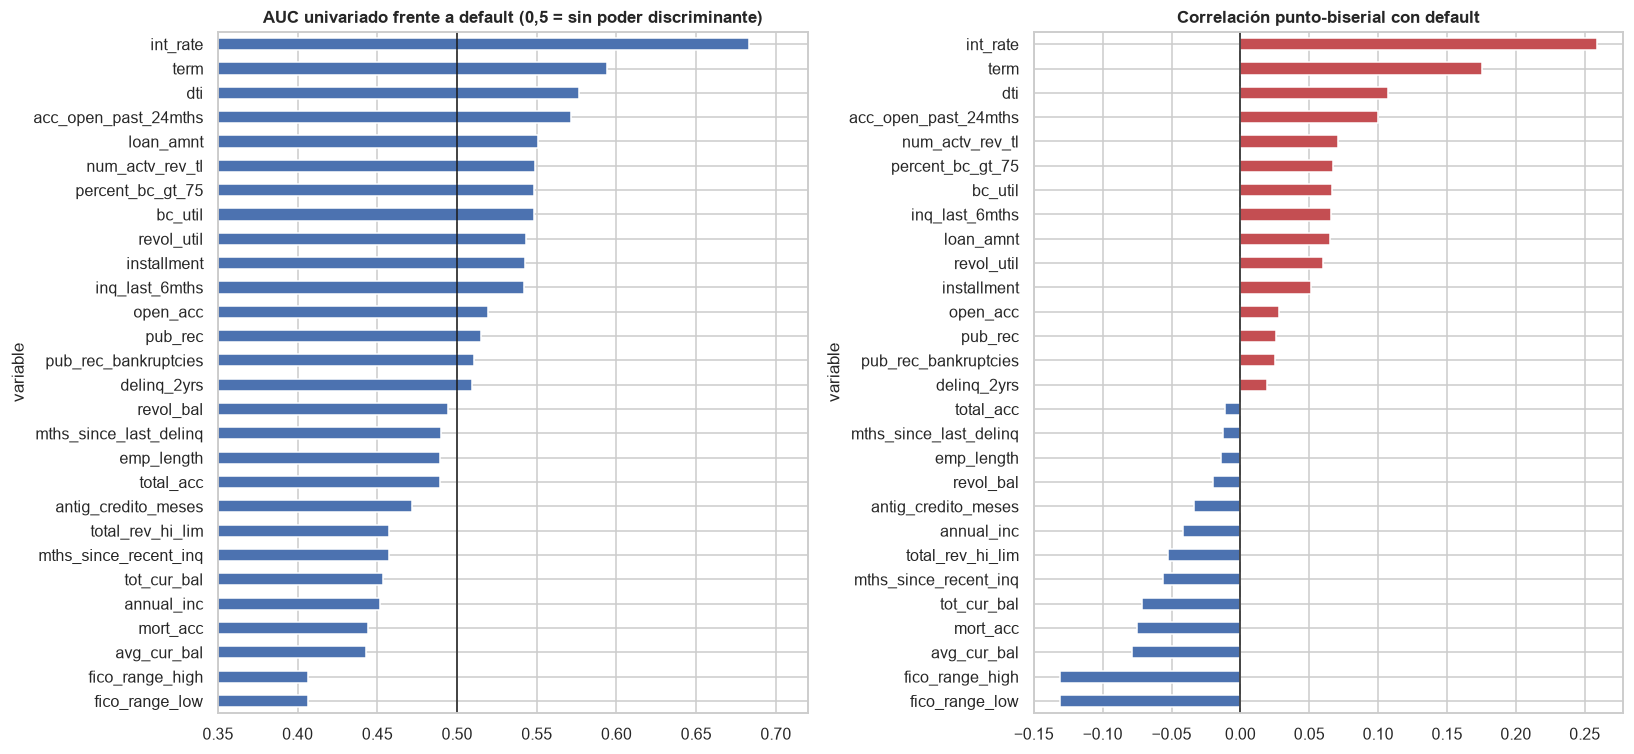

Variables con p de Mann-Whitney >= 0,05: []


In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 7))
biv["AUC_univariado"].sort_values().plot.barh(ax=a1, color="#4C72B0")
a1.axvline(0.5, color="k", lw=1)
a1.set_xlim(0.35, 0.72)
a1.set_title("AUC univariado frente a default (0,5 = sin poder discriminante)")
biv["r_punto_biserial"].sort_values().plot.barh(
    ax=a2, color=np.where(biv["r_punto_biserial"].sort_values() > 0, "#C44E52", "#4C72B0"))
a2.axvline(0, color="k", lw=1)
a2.set_title("Correlación punto-biserial con default")
fig.tight_layout()
u.guardar_fig(fig, "03_auc_univariado")
plt.show()
print("Variables con p de Mann-Whitney >= 0,05:", list(biv.index[biv["p_MannWhitney"] >= 0.05]))

**Resultados.** Todas las diferencias entre clases son estadísticamente significativas
(el mayor valor p de las tres pruebas, impreso arriba, es del orden de 10⁻¹⁹), algo esperable con
1,3 millones de datos. La magnitud es lo que
distingue a las variables:

* `int_rate` es, de lejos, la más discriminante: AUC univariado de 0,683 y correlación
  punto-biserial de 0,26. Los préstamos en default pagan en promedio 3,1 puntos más de interés.
* Le siguen `term` (AUC 0,594), el puntaje FICO (0,407, es decir, 0,593 en sentido inverso),
  `dti` (0,577) y `acc_open_past_24mths` (0,571).
* Las variables de patrimonio (`avg_cur_bal`, `mort_acc`, `tot_cur_bal`, `annual_inc`) tienen un
  efecto protector moderado (AUC entre 0,44 y 0,45).
* Los conteos de moras y registros públicos, `emp_length`, `total_acc` y `revol_bal` tienen AUC
  univariados entre 0,48 y 0,52: diferencias significativas pero prácticamente nulas.

La correlación punto-biserial ordena las variables de forma parecida al AUC. Como la de Pearson,
es sensible a la asimetría y a los valores extremos, y por eso reordena algunas variables
asimétricas: `annual_inc` baja del puesto 12 por AUC al 19 por correlación, y `tot_cur_bal` sube
del 14 al 9.

## 3.2 Variables categóricas frente a `default`

### 3.2.1 Tablas de contingencia y tasa de default por categoría

In [6]:
tasa_global = y.mean()
for c in u.CAT_EDA:
    ct = pd.crosstab(df[c], df["default"])
    ct.columns = ["pagado", "default"]
    ct["n"] = ct.sum(axis=1)
    ct["tasa_default_%"] = (100 * ct["default"] / ct["n"]).round(2)
    ct["riesgo_relativo"] = (ct["tasa_default_%"] / (100 * tasa_global)).round(2)
    ct = ct.sort_values("tasa_default_%", ascending=False)
    print(f"\n=== {c} ===")
    print(ct.to_string() if len(ct) <= 15 else pd.concat([ct.head(6), ct.tail(6)]).to_string())


=== grade ===
       pagado  default       n  tasa_default_%  riesgo_relativo
grade                                                          
G        4694     4632    9326           49.67             2.49
F       17721    14584   32305           45.14             2.26
E       57993    36193   94186           38.43             1.92
D      140393    61251  201644           30.38             1.52
C      296518    85797  382315           22.44             1.12
B      340441    52654  393095           13.39             0.67
A      220979    14209  235188            6.04             0.30

=== purpose ===
                    pagado  default       n  tasa_default_%  riesgo_relativo
purpose                                                                     
small_business       10925     4652   15577           29.86             1.49
renewable_energy       714      222     936           23.72             1.19
moving                7297     2229    9526           23.40             1.17
house  


=== addr_state ===
            pagado  default      n  tasa_default_%  riesgo_relativo
addr_state                                                         
MS            4873     1722   6595           26.11             1.31
NE            2686      906   3592           25.22             1.26
AR            7636     2426  10062           24.11             1.21
AL           12711     3934  16645           23.63             1.18
OK            9412     2886  12298           23.47             1.17
LA           11926     3598  15524           23.18             1.16
WV            4129      759   4888           15.53             0.78
NH            5523      942   6465           14.57             0.73
OR           14057     2366  16423           14.41             0.72
VT            2284      371   2655           13.97             0.70
ME            1749      281   2030           13.84             0.69
DC            3024      461   3485           13.23             0.66

=== verification_status ===


=== application_type ===
                   pagado  default        n  tasa_default_%  riesgo_relativo
application_type                                                            
Joint App           19456     6344    25800           24.59             1.23
Individual        1059283   262976  1322259           19.89             1.00

=== initial_list_status ===
                     pagado  default       n  tasa_default_%  riesgo_relativo
initial_list_status                                                          
w                    625570   158440  784010           20.21             1.01
f                    453169   110880  564049           19.66             0.98


La calificación `grade` produce el gradiente más fuerte: la tasa de default pasa de 6,0 % en A a
49,7 % en G, un riesgo relativo de 0,30 a 2,49. Entre los propósitos destaca `small_business`
(29,9 %) y, en el otro extremo, `wedding` (12,4 %) y `car` (14,7 %). Los arrendatarios (`RENT`,
23,2 %) incumplen más que quienes tienen hipoteca (17,2 %). Llama la atención que los ingresos
verificados tengan **más** default (23,9 %) que los no verificados (14,7 %): Lending Club
verificaba con más frecuencia a los solicitantes de mayor riesgo, así que la verificación es un
marcador de riesgo y no una garantía. Por estado, la tasa varía entre 13,2 % (DC) y 26,1 % (MS).

### 3.2.2 Barras apiladas de la proporción de default

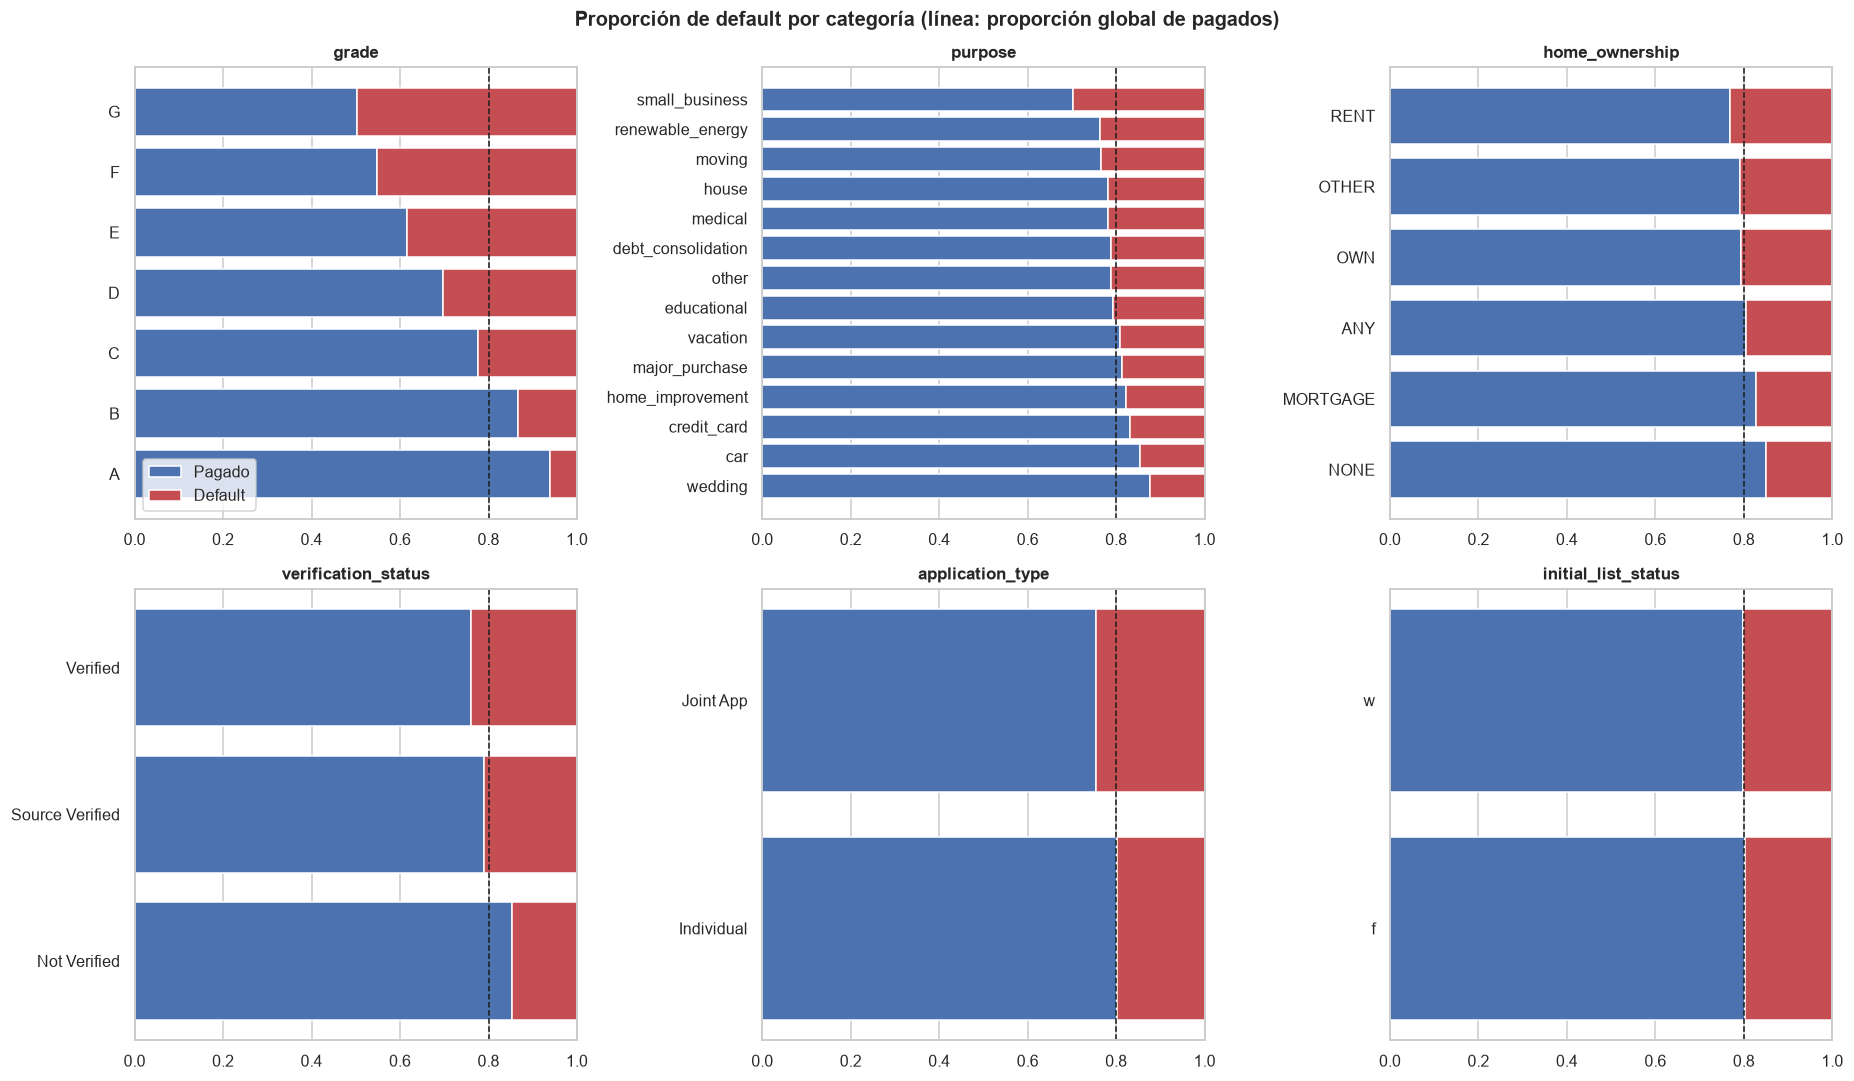

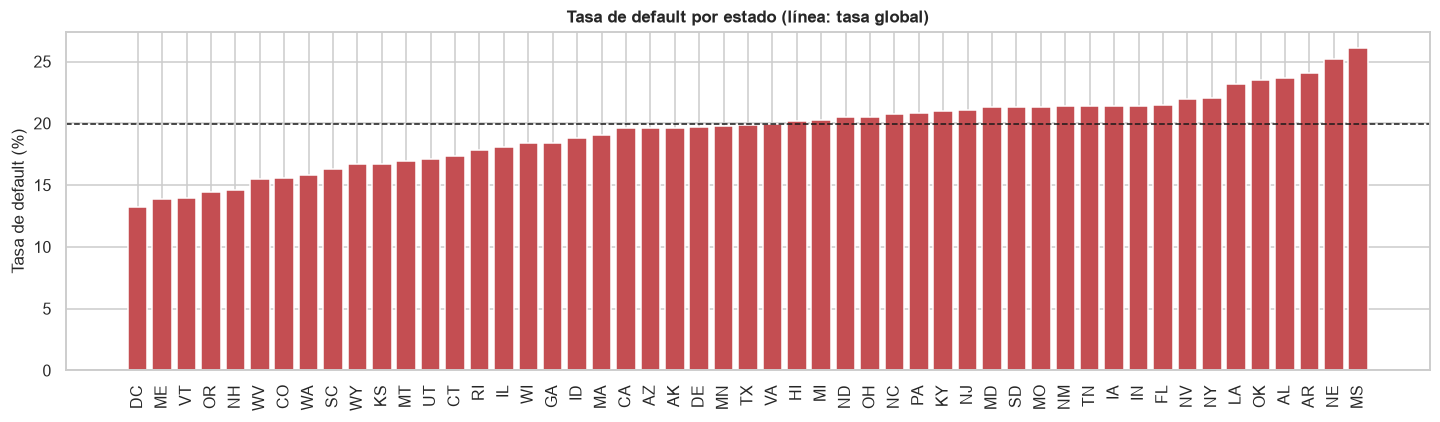

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, c in zip(axes.ravel(), ["grade", "purpose", "home_ownership", "verification_status",
                                "application_type", "initial_list_status"]):
    prop = pd.crosstab(df[c], df["default"], normalize="index").sort_values(1)
    ax.barh(prop.index.astype(str), prop[0], color=u.PALETA[0], label="Pagado")
    ax.barh(prop.index.astype(str), prop[1], left=prop[0], color=u.PALETA[1], label="Default")
    ax.axvline(1 - tasa_global, color="k", ls="--", lw=1)
    ax.set_title(c)
    ax.set_xlim(0, 1)
axes[0, 0].legend(loc="lower left")
fig.suptitle("Proporción de default por categoría (línea: proporción global de pagados)",
             fontsize=13, weight="bold")
fig.tight_layout()
u.guardar_fig(fig, "03_barras_apiladas")
plt.show()

fig, ax = plt.subplots(figsize=(16, 4))
tasa_estado = (100 * df.groupby("addr_state")["default"].mean()).sort_values()
ax.bar(tasa_estado.index, tasa_estado.values, color="#C44E52")
ax.axhline(100 * tasa_global, color="k", ls="--", lw=1)
ax.set_ylabel("Tasa de default (%)")
ax.set_title("Tasa de default por estado (línea: tasa global)")
ax.tick_params(axis="x", rotation=90)
u.guardar_fig(fig, "03_default_estado")
plt.show()

Las barras apiladas muestran visualmente lo que las tablas cuantifican. En `grade` la proporción
de default crece de forma monótona de A a G; en `initial_list_status` y `application_type` las
barras casi coinciden con la línea de referencia (19,7 % y 20,2 % en `initial_list_status`). En
`application_type` la categoría `Joint App` sí se aparta (24,6 %, riesgo relativo 1,23), pero
agrupa solo el 1,9 % de los préstamos, y por eso su asociación global es despreciable.

### 3.2.3 Prueba de independencia chi-cuadrado y V de Cramér

In [8]:
chi = pd.DataFrame([dict(zip(["V_Cramer", "chi2", "p", "gl"], est.cramer_v(df[c], y)), variable=c)
                    for c in u.CAT_EDA]).set_index("variable").sort_values("V_Cramer", ascending=False)
chi.assign(p=chi["p"].map("{:.2e}".format)).round({"V_Cramer": 4, "chi2": 1})

,V_Cramer,chi2,p,gl
variable,,,,
grade,0.2617,92310.1,0.00e+00,6
verification_status,0.0914,11271.0,0.00e+00,2
home_ownership,0.0706,6732.8,0.00e+00,5
purpose,0.0556,4182.8,0.00e+00,13
addr_state,0.0499,3402.3,0.00e+00,50
application_type,0.0161,349.8,4.73e-78,1
initial_list_status,0.0067,62.3,2.93e-15,1


La prueba chi-cuadrado rechaza la independencia para las siete variables (p < 10⁻¹⁴), otra vez
por el tamaño de la muestra. La V de Cramér da la magnitud: `grade` tiene una asociación moderada
con `default` (V = 0,26); `verification_status`, `home_ownership`, `purpose` y `addr_state`
tienen asociaciones débiles (V entre 0,05 y 0,09); `application_type` e `initial_list_status`
tienen asociaciones despreciables (V < 0,02). Se conservan estas dos últimas porque su costo es
de solo una columna binaria cada una, y los modelos regularizados y los árboles pueden ignorarlas.

## 3.3 Relaciones entre variables independientes

### 3.3.1 Matriz de correlación de Pearson

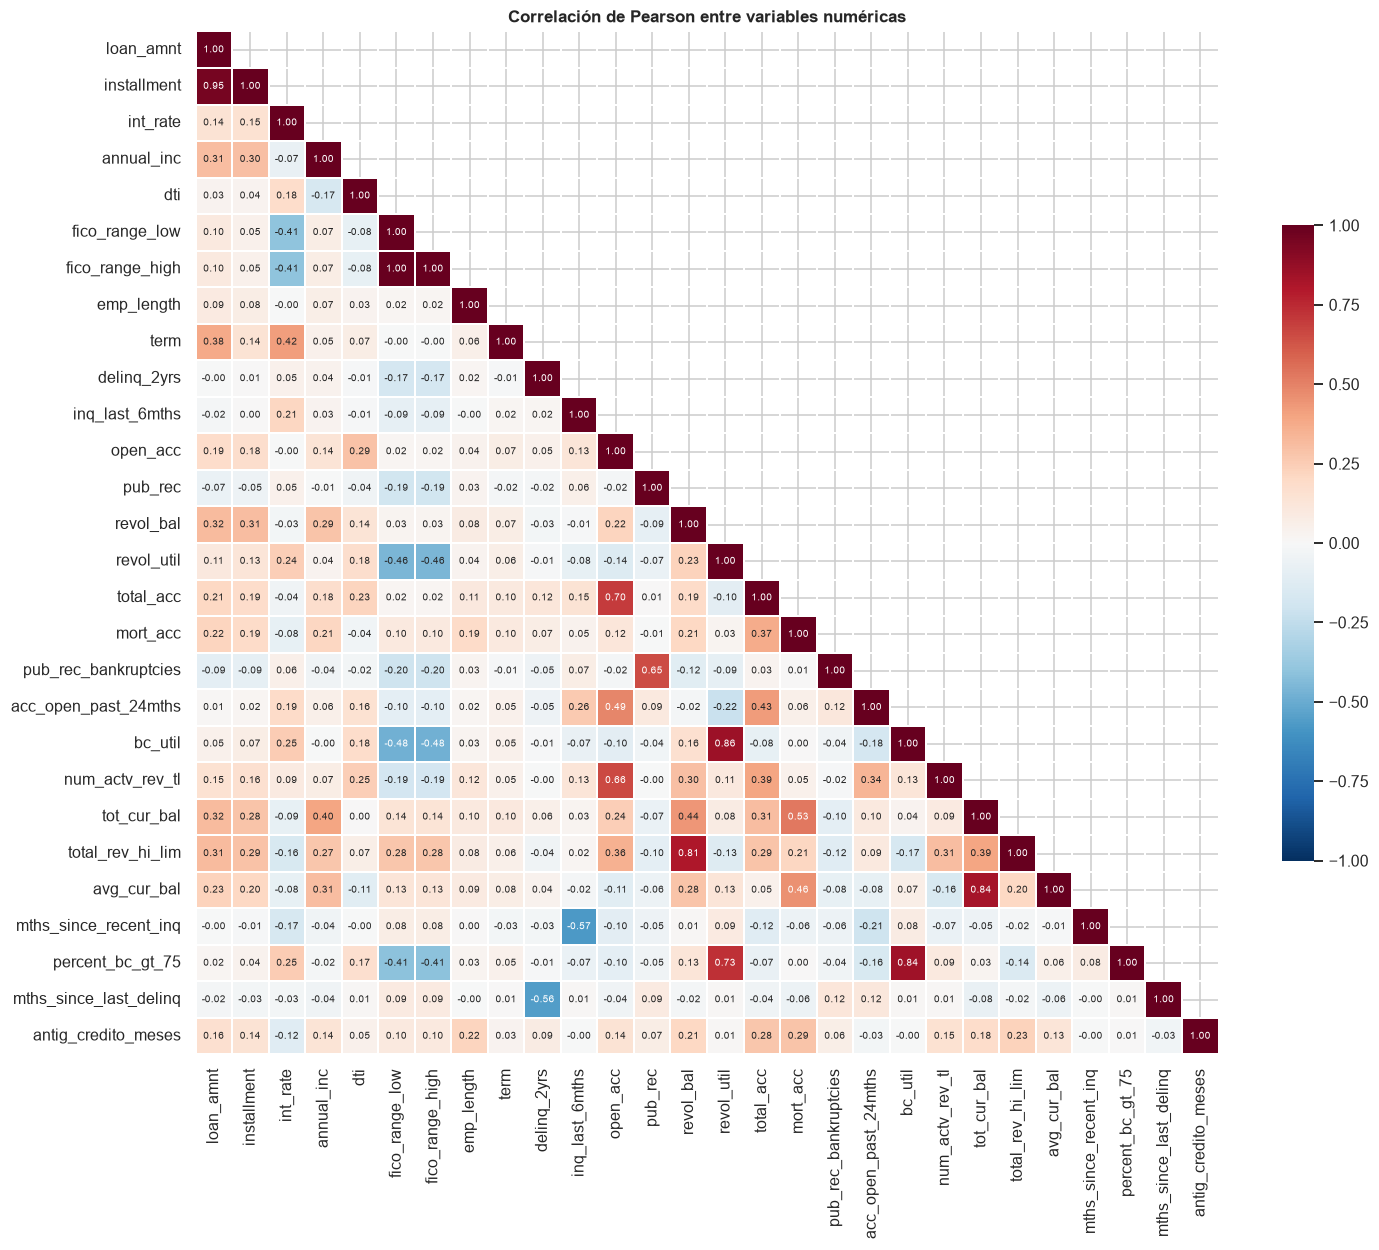

,var_1,var_2,r
125,fico_range_low,fico_range_high,1.000
0,loan_amnt,installment,0.953
291,revol_util,bc_util,0.855
347,bc_util,percent_bc_gt_75,0.845
358,tot_cur_bal,avg_cur_bal,0.835
281,revol_bal,total_rev_hi_lim,0.810
297,revol_util,percent_bc_gt_75,0.727
245,open_acc,total_acc,0.701


In [9]:
corr = df[u.NUM_EDA].corr(method="pearson")
fig, ax = plt.subplots(figsize=(15, 12.5))
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mascara, cmap="RdBu_r", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 6.5}, square=True, linewidths=0.3, cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Correlación de Pearson entre variables numéricas")
u.guardar_fig(fig, "03_correlacion")
plt.show()

pares = (corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1)).stack().rename("r")
         .reset_index().rename(columns={"level_0": "var_1", "level_1": "var_2"}))
altos = pares[pares["r"].abs() > 0.7].sort_values("r", key=np.abs, ascending=False)
altos.round(3)

Ocho pares superan $|r| = 0{,}7$. Todos tienen una explicación contable:

| Par | r | Explicación | Decisión |
|---|---|---|---|
| `fico_range_low` - `fico_range_high` | 1,000 | el rango FICO mide 4 puntos en prácticamente todos los préstamos | se conserva `fico_range_high` |
| `loan_amnt` - `installment` | 0,953 | la cuota es función del monto, la tasa y el plazo | se conserva `loan_amnt` (AUC más alto) |
| `revol_util` - `bc_util` | 0,855 | utilización rotativa total y de tarjetas bancarias | se conserva `revol_util` (0,07 % de faltantes frente a 4,8 %, capítulo 2) |
| `bc_util` - `percent_bc_gt_75` | 0,845 | ambas miden uso de tarjetas | se eliminan ambas |
| `tot_cur_bal` - `avg_cur_bal` | 0,835 | el promedio es el total entre el número de cuentas | se conserva `avg_cur_bal` (AUC más alto) |
| `revol_bal` - `total_rev_hi_lim` | 0,810 | saldo y límite rotativo; su cociente es `revol_util` | se conserva `total_rev_hi_lim` |
| `revol_util` - `percent_bc_gt_75` | 0,727 | ambas miden utilización | se elimina `percent_bc_gt_75` |
| `open_acc` - `total_acc` | 0,701 | cuentas abiertas y cuentas totales | se conserva `open_acc` (AUC más alto) |

Cuando se elimina una variable de un par, su pareja conserva entre el 49 % ($r^2$ de `open_acc` y
`total_acc`) y el 100 % (FICO) de su variación lineal; la pérdida es mínima en los pares con
$r \geq 0{,}95$ y moderada en los demás.

La exclusión no busca mejorar el AUC de los árboles, que toleran la colinealidad, sino
estabilizar los coeficientes de la regresión logística y del SVM lineal y respetar el supuesto
de independencia condicional de Naive Bayes.

### 3.3.2 Asociación entre variables categóricas (V de Cramér)

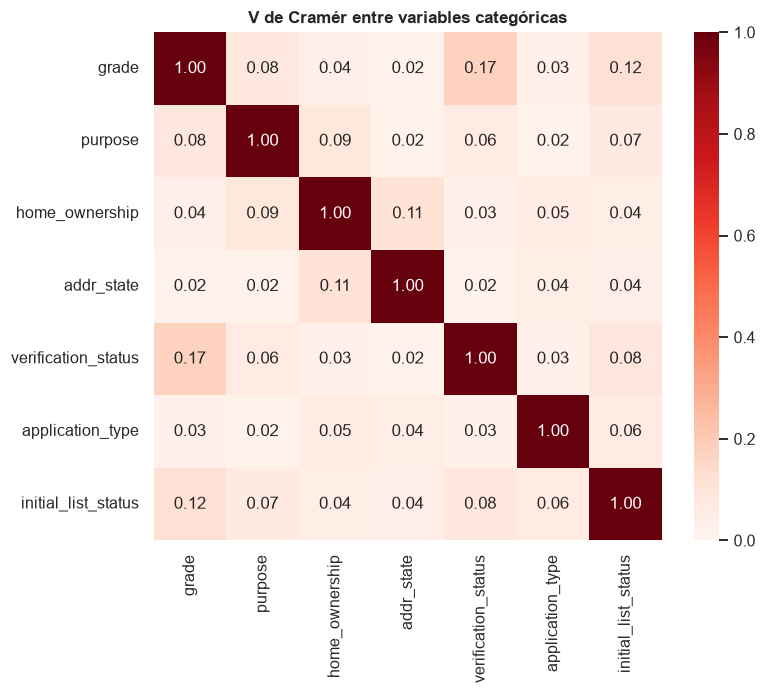

,grade,purpose,home_ownership,addr_state,verification_status,application_type,initial_list_status
grade,1.000,0.083,0.038,0.017,0.175,0.025,0.119
purpose,0.083,1.000,0.086,0.021,0.062,0.021,0.068
home_ownership,0.038,0.086,1.000,0.111,0.029,0.052,0.043
addr_state,0.017,0.021,0.111,1.000,0.021,0.044,0.040
verification_status,0.175,0.062,0.029,0.021,1.000,0.030,0.076
application_type,0.025,0.021,0.052,0.044,0.030,1.000,0.062
initial_list_status,0.119,0.068,0.043,0.040,0.076,0.062,1.000


In [10]:
cats = u.CAT_EDA
V = pd.DataFrame(np.eye(len(cats)), index=cats, columns=cats)
for i, a in enumerate(cats):
    for b in cats[i + 1:]:
        V.loc[a, b] = V.loc[b, a] = est.cramer_v(df[a], df[b])[0]
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(V, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1, square=True, ax=ax)
ax.set_title("V de Cramér entre variables categóricas")
u.guardar_fig(fig, "03_cramer")
plt.show()
V.round(3)

Las asociaciones entre variables categóricas son débiles: la mayor es entre `grade` y
`verification_status` (V = 0,18), coherente con que se verificaban más los préstamos riesgosos, y
ninguna justifica eliminar una variable.

### 3.3.3 Redundancias entre la calificación, la tasa de interés y el puntaje FICO

`grade` es categórica y `int_rate` numérica; su asociación se mide con la razón de correlación
$\eta^2$ (proporción de la varianza de `int_rate` explicada por `grade`).

eta² de int_rate explicada por grade:        0.907
eta² de fico_range_high explicada por grade: 0.235
r de Pearson int_rate - fico_range_high:     -0.406
r de Pearson fico_range_low - fico_range_high: 1.0000


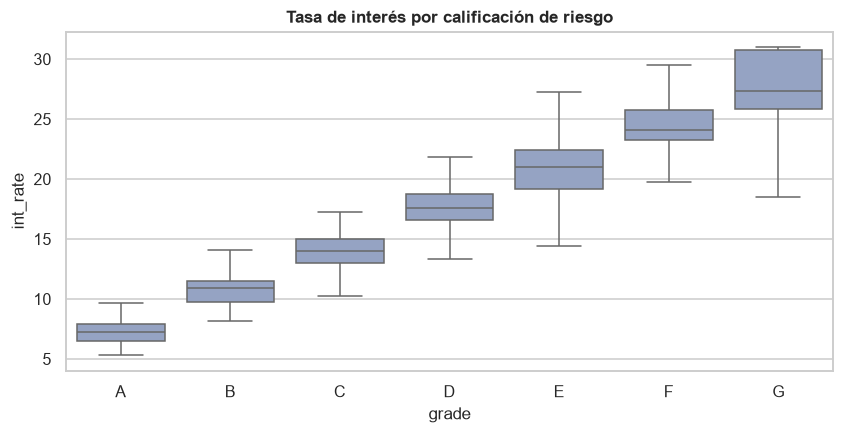

In [11]:
def eta2(cat, num):
    d = pd.DataFrame({"c": cat, "x": num}).dropna()
    media = d["x"].mean()
    entre = d.groupby("c")["x"].agg(["size", "mean"]).pipe(lambda g: (g["size"] * (g["mean"] - media) ** 2).sum())
    return entre / ((d["x"] - media) ** 2).sum()


print(f"eta² de int_rate explicada por grade:        {eta2(df['grade'], df['int_rate']):.3f}")
print(f"eta² de fico_range_high explicada por grade: {eta2(df['grade'], df['fico_range_high']):.3f}")
print(f"r de Pearson int_rate - fico_range_high:     {corr.loc['int_rate', 'fico_range_high']:.3f}")
print(f"r de Pearson fico_range_low - fico_range_high: {corr.loc['fico_range_low', 'fico_range_high']:.4f}")
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df, x="grade", y="int_rate", order=list("ABCDEFG"), color="#8DA0CB",
            showfliers=False, ax=ax)
ax.set_title("Tasa de interés por calificación de riesgo")
u.guardar_fig(fig, "03_grade_int_rate")
plt.show()

`grade` explica el 90,7 % de la varianza de `int_rate`: Lending Club fija la tasa a partir de la
subcalificación, así que ambas miden lo mismo y `int_rate` contiene la información de `grade`
con más resolución. Se excluyen `grade` y `sub_grade` del modelado. La relación entre FICO e
`int_rate` que sugiere el enunciado existe (r = −0,41; `grade` explica el 23,5 % de la varianza
de FICO), pero está lejos de la redundancia: el FICO es una de las entradas del precio, no el
precio mismo, y ambas variables se conservan.

## 3.4 Visualizaciones avanzadas

### 3.4.1 Pairplot de las variables principales

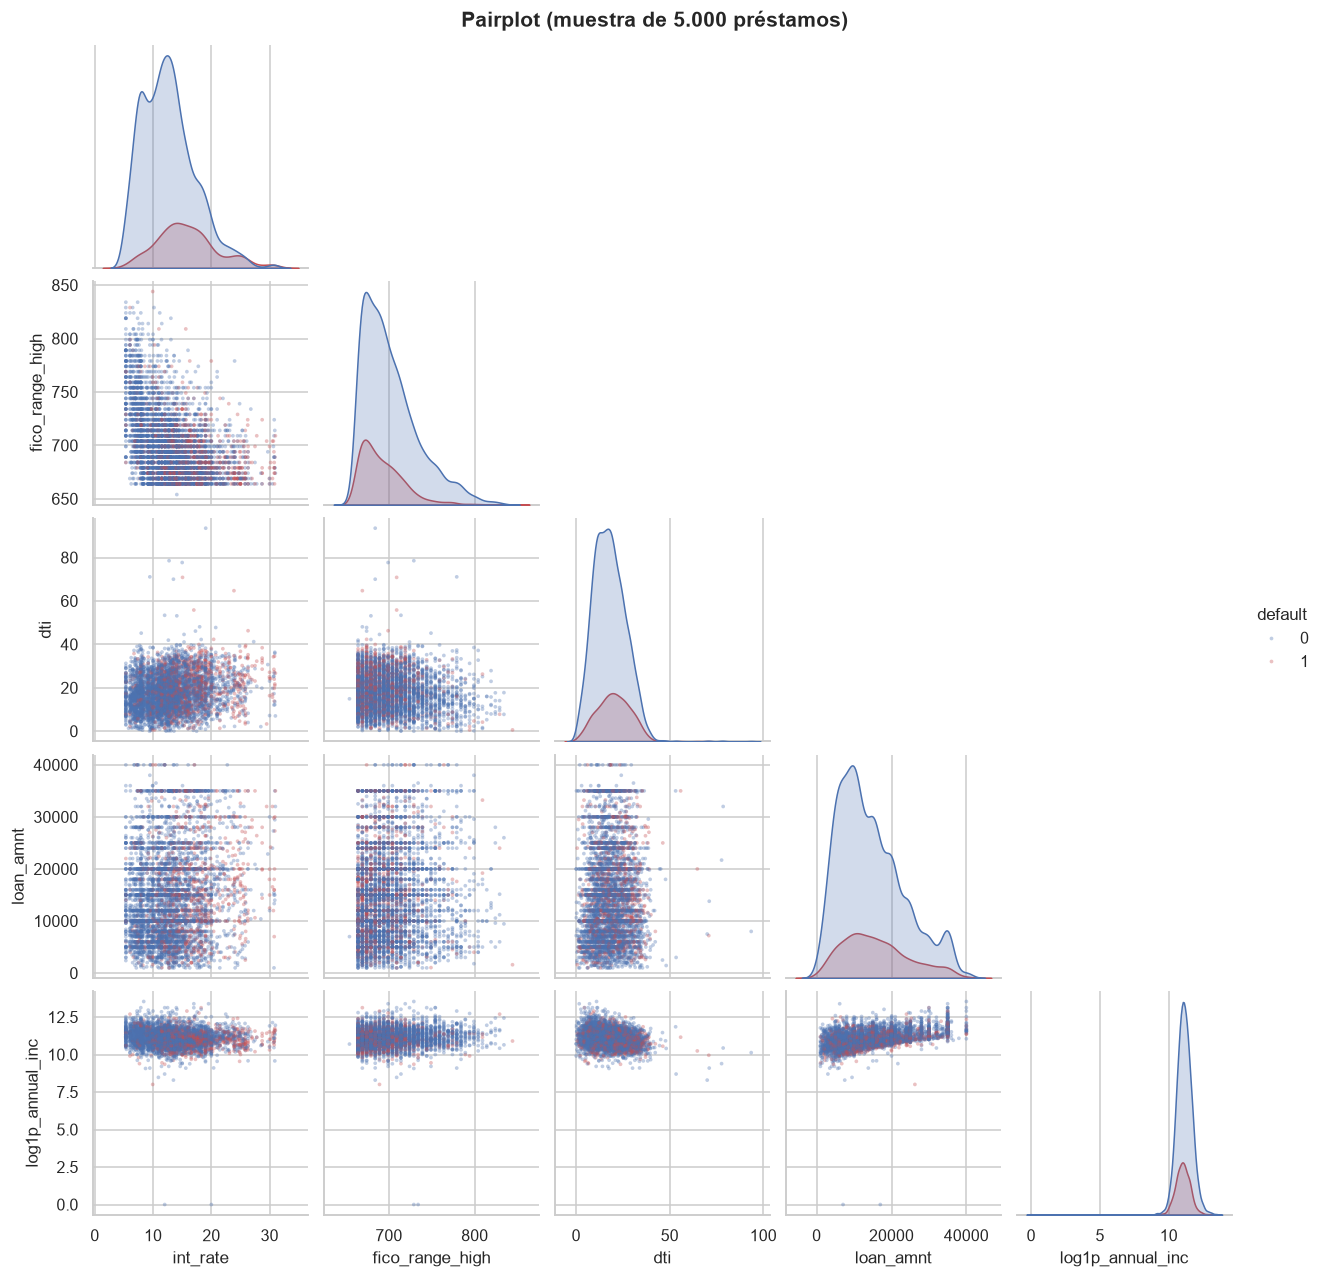

In [12]:
vars_pp = ["int_rate", "fico_range_high", "dti", "loan_amnt", "annual_inc"]
pp = muestra_chica[vars_pp + ["default"]].copy()
pp["annual_inc"] = np.log1p(pp["annual_inc"])
pp = pp.rename(columns={"annual_inc": "log1p_annual_inc"})
g = sns.pairplot(pp, hue="default", palette=u.PALETA, corner=True, diag_kind="kde",
                 plot_kws={"s": 6, "alpha": 0.35, "linewidth": 0}, height=2.3)
g.figure.suptitle("Pairplot (muestra de 5.000 préstamos)", y=1.01, weight="bold")
g.savefig(u.FIGURAS / "03_pairplot.png")
plt.show()

El pairplot no muestra fronteras nítidas entre clases en ningún par de variables: los defaults
(rojo) se concentran en la zona de tasa alta y FICO bajo, pero mezclados con préstamos pagados.
La relación negativa entre `int_rate` y `fico_range_high` y la positiva entre `loan_amnt` e
ingreso son las únicas visibles. Se espera, por tanto, un AUC moderado (del orden de 0,70) y no
una separación casi perfecta.

### 3.4.2 Densidades comparativas (KDE) por clase

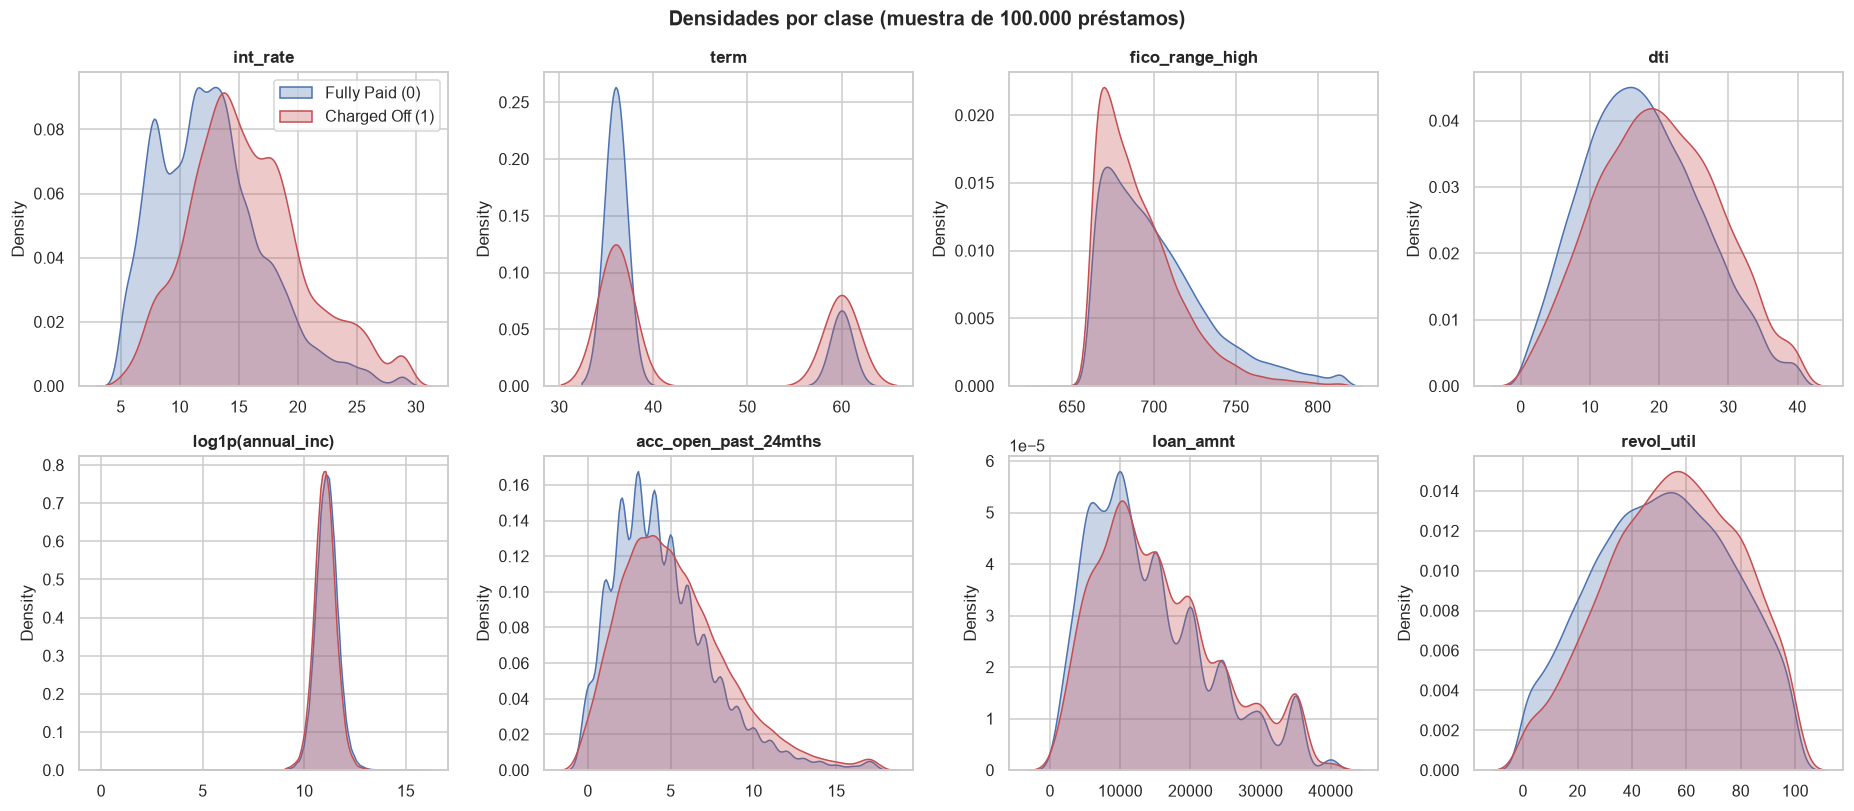

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7.5))
for ax, c in zip(axes.ravel(), clave):
    d = muestra[[c, "default"]].dropna()
    if c == "annual_inc":
        d[c] = np.log1p(d[c])
    else:
        d[c] = d[c].clip(upper=d[c].quantile(0.995))
    for k in (0, 1):
        sns.kdeplot(d.loc[d["default"] == k, c], ax=ax, fill=True, alpha=0.3, color=u.PALETA[k],
                    label=u.ETIQUETAS[k], common_norm=False, bw_adjust=1.2)
    ax.set_title("log1p(annual_inc)" if c == "annual_inc" else c)
    ax.set_xlabel("")
axes[0, 0].legend()
fig.suptitle("Densidades por clase (muestra de 100.000 préstamos)", fontsize=13, weight="bold")
fig.tight_layout()
u.guardar_fig(fig, "03_kde")
plt.show()

Las densidades por clase se solapan en gran parte de su rango. El desplazamiento es claro en
`int_rate`, `term` (más plazos de 60 meses entre los defaults) y `fico_range_high`, moderado en
`dti` y `acc_open_past_24mths` y pequeño en `annual_inc`, `loan_amnt` y `revol_util`.

### 3.4.3 Matriz de dispersión

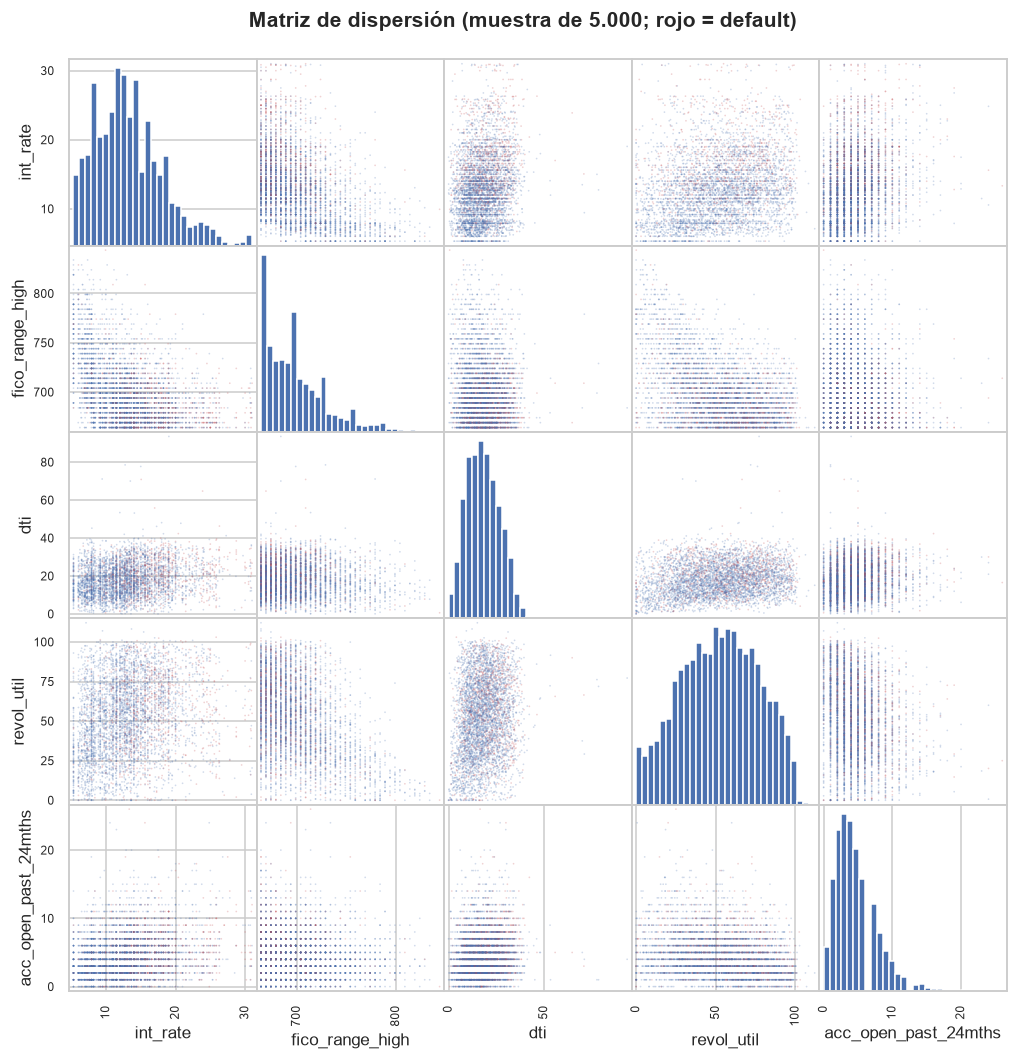

In [14]:
sm = muestra_chica[["int_rate", "fico_range_high", "dti", "revol_util", "acc_open_past_24mths",
                    "default"]].dropna()
ejes = pd.plotting.scatter_matrix(sm.drop(columns="default"), figsize=(11, 11), alpha=0.25, s=5,
                                  diagonal="hist", c=sm["default"].map(u.PALETA), hist_kwds={"bins": 30})
plt.suptitle("Matriz de dispersión (muestra de 5.000; rojo = default)", weight="bold", y=0.92)
plt.savefig(u.FIGURAS / "03_scatter_matrix.png")
plt.show()

La matriz de dispersión no revela relaciones no lineales fuertes entre las variables clave. Las
nubes son difusas, salvo la frontera inferior de `fico_range_high` y la estructura en bandas de
`int_rate`, que refleja la grilla discreta de tasas de Lending Club.